In [1]:
import pandas as pd
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Dropout
from tensorflow.keras.optimizers import Adam
import ast

In [2]:
df= pd.read_csv("C:/Users/85290/OneDrive - The Chinese University of Hong Kong/stat4012/hotel_reviews_with_topics_indexed.csv")
# Check if the 'review_indexed_padded' column is a string or list
def safe_convert(value):
    try:
        # If the value is a string representation of a list, convert it to a list
        if isinstance(value, str):
            return ast.literal_eval(value)
        elif isinstance(value, list):
            return value
        else:
            return None  # Return None if it's neither a string nor a list
    except Exception as e:
        print(f"Error converting value: {value}, Error: {e}")
        return None

# Apply the conversion function
df['review_indexed_padded'] = df['review_indexed_padded'].apply(safe_convert)
# Clean up any unwanted characters (e.g., extra spaces, quotes)
df['review_indexed_padded'] = df['review_indexed_padded'].apply(lambda x: str(x).strip())

# Now try to safely convert the string representation of a list to an actual list
df['review_indexed_padded'] = df['review_indexed_padded'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Pad the sequences (you can choose a max length, e.g., 100)
max_sequence_length = 200  # Choose a max length based on your data

X_reviews_padded = pad_sequences(df['review_indexed_padded'].tolist(), maxlen=max_sequence_length, padding='post')
from sklearn.preprocessing import LabelEncoder
df['Rating'] = LabelEncoder().fit_transform(df['Rating'])

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Number of classes in your target
num_classes = len(df['Rating'].unique())  # Make sure labels are 0-indexed

# Pad sequences
X_reviews_padded = pad_sequences(df['review_indexed_padded'].tolist(), padding='post', maxlen=200)

# Calculate vocab size
vocab_size = max([max(seq) for seq in df['review_indexed_padded'].tolist()]) + 1

# One-hot encode labels
y = to_categorical(df['Rating'].values)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_reviews_padded, y, test_size=0.2, random_state=42)

# Define callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1, min_lr=1e-6)

# Build model
model = Sequential()
model.add(Input(shape=(200,)))
model.add(Embedding(input_dim=vocab_size, output_dim=128))
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(64, return_sequences=False, dropout=0.2)))
model.add(BatchNormalization())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

# Compile
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Train
model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, lr_scheduler]
)

# Predict class probabilities
y_pred_probs = model.predict(X_test)

# Predicted class labels
y_pred_classes = y_pred_probs.argmax(axis=1)


Epoch 1/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 48s 88ms/step - accuracy: 0.4740 - loss: 1.2301 - val_accuracy: 0.5262 - val_loss: 1.0984 - learning_rate: 0.0010
Epoch 2/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 48s 94ms/step - accuracy: 0.6490 - loss: 0.8179 - val_accuracy: 0.6090 - val_loss: 0.9043 - learning_rate: 0.0010
Epoch 3/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 56s 110ms/step - accuracy: 0.7194 - loss: 0.6746 - val_accuracy: 0.6072 - val_loss: 0.9588 - learning_rate: 0.0010
Epoch 4/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7783 - loss: 0.5510
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
508/508 ━━━━━━━━━━━━━━━━━━━━ 46s 91ms/step - accuracy: 0.7782 - loss: 0.5510 - val_accuracy: 0.5949 - val_loss: 1.0841 - learning_rate: 0.0010
Epoch 5/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 46s 90ms/step - accuracy: 0.8315 - loss: 0.4232 - val_accuracy: 0.6006 - val_loss: 1.1409 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best 

127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
Accuracy: 0.6090
Precision (Macro): 0.5307
Recall (Macro): 0.5579
F1 Score (Macro): 0.5419


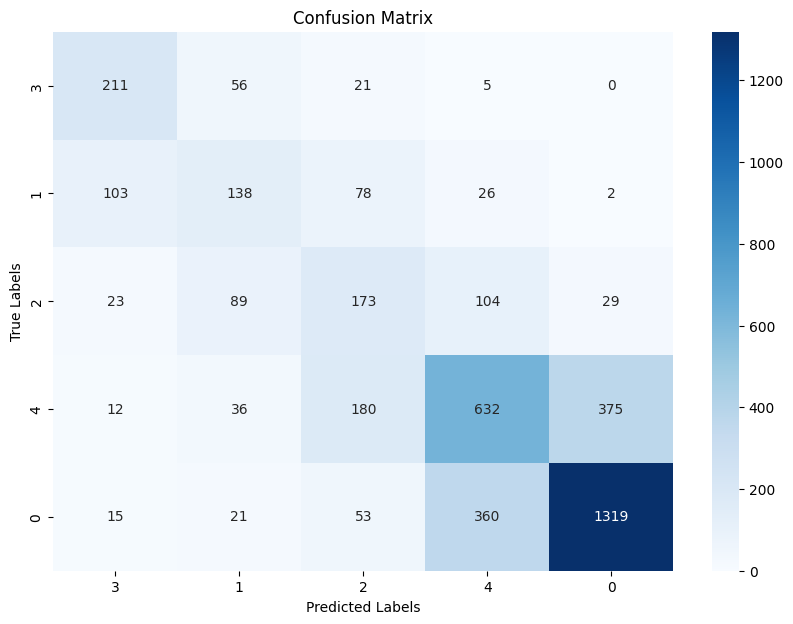


Per-Class Metrics:
Class 0:
  Precision: 0.5797
  Recall: 0.7201
  F1 Score: 0.6423
Class 1:
  Precision: 0.4059
  Recall: 0.3977
  F1 Score: 0.4017
Class 2:
  Precision: 0.3426
  Recall: 0.4139
  F1 Score: 0.3749
Class 3:
  Precision: 0.5608
  Recall: 0.5117
  F1 Score: 0.5351
Class 4:
  Precision: 0.7646
  Recall: 0.7460
  F1 Score: 0.7552


In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict the class labels
y_pred_classes = model.predict(X_test).argmax(axis=1)  # Get predicted class labels

# Actual class labels
y_true = y_test.argmax(axis=1)  # If y_test is one-hot encoded, convert to integer labels

# 1. Accuracy Score
accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

# 2. Precision, Recall, and F1 Score (macro averaged)
precision = precision_score(y_true, y_pred_classes, average='macro')
recall = recall_score(y_true, y_pred_classes, average='macro')
f1 = f1_score(y_true, y_pred_classes, average='macro')

print(f"Precision (Macro): {precision:.4f}")
print(f"Recall (Macro): {recall:.4f}")
print(f"F1 Score (Macro): {f1:.4f}")

# 3. Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Visualizing confusion matrix using Seaborn
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=df['Rating'].unique(), yticklabels=df['Rating'].unique())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# If you'd like per-class metrics (for precision, recall, f1)
print("\nPer-Class Metrics:")
for i in range(num_classes):
    print(f"Class {i}:")
    print(f"  Precision: {precision_score(y_true, y_pred_classes, average=None)[i]:.4f}")
    print(f"  Recall: {recall_score(y_true, y_pred_classes, average=None)[i]:.4f}")
    print(f"  F1 Score: {f1_score(y_true, y_pred_classes, average=None)[i]:.4f}")



Classification Report:

              precision    recall  f1-score   support

           0       0.58      0.72      0.64       293
           1       0.41      0.40      0.40       347
           2       0.34      0.41      0.37       418
           3       0.56      0.51      0.54      1235
           4       0.76      0.75      0.76      1768

    accuracy                           0.61      4061
   macro avg       0.53      0.56      0.54      4061
weighted avg       0.62      0.61      0.61      4061

127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


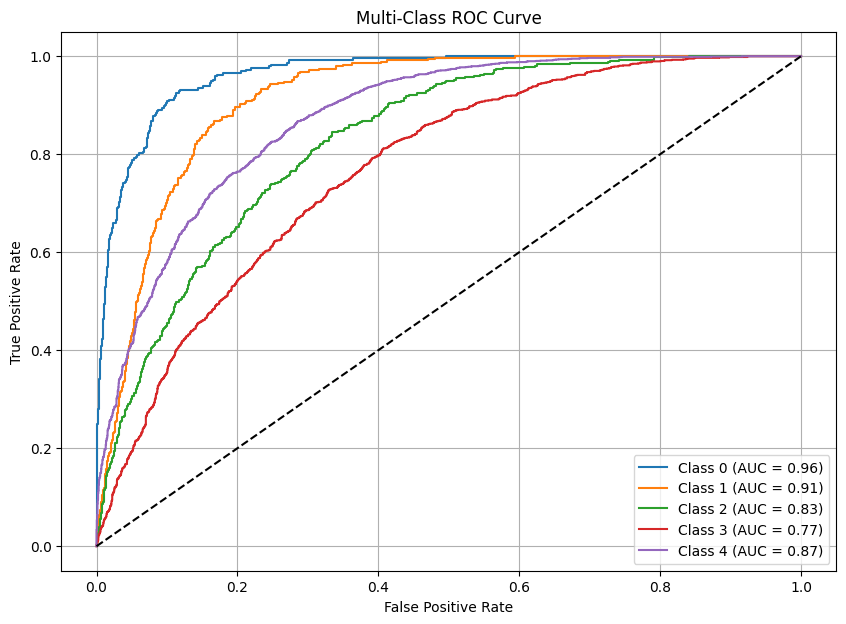

In [5]:
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize

# ----------------------------
# Classification Report
# ----------------------------
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes))

# ----------------------------
# ROC Curve (One-vs-Rest)
# ----------------------------

# Binarize the true labels
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

# Predict class probabilities (already done if you saved earlier)
y_pred_probs = model.predict(X_test)

# Plot ROC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 7))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal
plt.title('Multi-Class ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()
